## Tree of Thoughts Notebook

Install Dependencies

In [ ]:
!pip install -q transformers accelerate datasets torch pandas


Load the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import Libraries

In [ ]:
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM


GPU set up

In [ ]:
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    major, minor = torch.cuda.get_device_capability()
    print(f"GPU detected: {gpu_name} (Compute capability {major}.{minor})")
    if major >= 8:
        torch_dtype = torch.bfloat16
    else:
        torch_dtype = torch.float16
else:
    print("No GPU detected. Using CPU.")
    torch_dtype = torch.float32


GPU detected: NVIDIA L4 (Compute capability 8.9)


Load Gemma Model

In [ ]:
from huggingface_hub import login
login()


In [ ]:
model_id = "google/gemma-3-4b-it"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch_dtype,
    device_map="auto"
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Load one example from mines.csv

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/mines.csv")


In [ ]:
import re

row = df.iloc[0]

raw_context = row["Context"]
raw_target  = row["Target"]

context_clean = re.sub(r"Mine Type:.*", "", raw_context)

m = re.search(r"Mine Type:\s*(.*)", raw_target)
if m:
    mine_type = m.group(1).strip()
else:
    mine_type = raw_target.strip()

prompt = f"""
{context_clean.strip()}
Mine Type: {mine_type}
"""


Tree of Thought Function

In [ ]:
from graphviz import Digraph

dot = Digraph('ToT_Pipeline')
dot.node('A', 'Input:\nVoltage\nHeight\nSoil Type\nMine Type', shape='ellipse')
dot.node('B', 'ToT Wrapper:\nGenerate k Reasoning Paths\n(temperature sampling)\nStep-by-step\nMust output:\nFinal Answer: Sensor', shape='box')
dot.node('C1', 'Reasoning Path 1', shape='box')
dot.node('C2', 'Reasoning Path 2', shape='box')
dot.node('C3', 'Reasoning Path k', shape='box')
dot.node('D1', 'Score Path 1\n(LLM Score)', shape='box')
dot.node('D2', 'Score Path 2\n(LLM Score)', shape='box')
dot.node('D3', 'Score Path k\n(LLM Score)', shape='box')
dot.node('E', 'Select Best Path\n(max score)', shape='diamond')
dot.node('F', 'Extract Sensor\n(robust regex)', shape='box')
dot.node('G', 'Extract Explanation\n(clean + filtered)', shape='box')
dot.node('I', 'Final Output:\nRecommendation + Explanation', shape='ellipse')
dot.edge('A', 'B')
dot.edge('B', 'C1')
dot.edge('B', 'C2')
dot.edge('B', 'C3')

dot.edge('C1', 'D1')
dot.edge('C2', 'D2')
dot.edge('C3', 'D3')

dot.edge('D1', 'E')
dot.edge('D2', 'E')
dot.edge('D3', 'E')

dot.edge('E', 'F')
dot.edge('F', 'G')
dot.edge('G', 'I')

dot.render('tot_diagram', format='png', cleanup=True)


'tot_diagram.png'

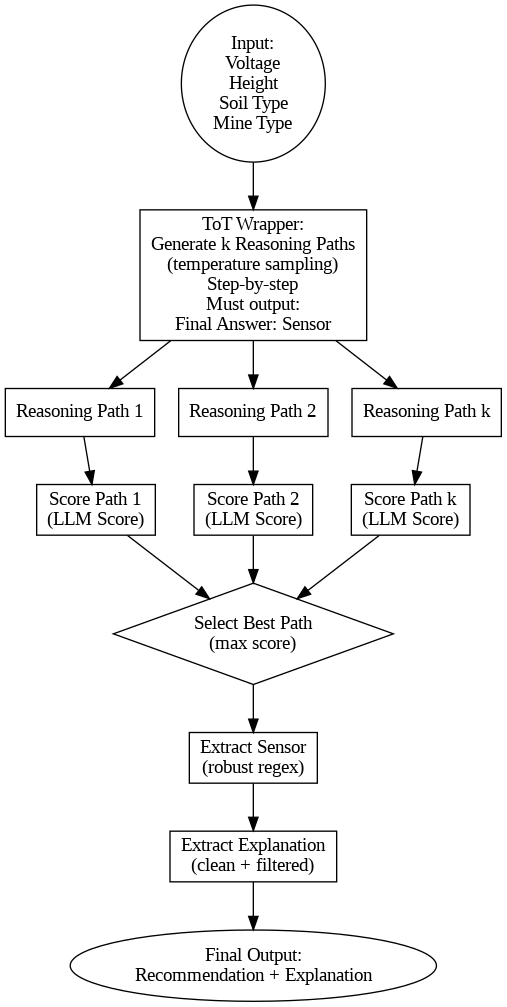

In [ ]:
from IPython.display import Image
Image('tot_diagram.png')

In [ ]:
import re
import torch

def tot_reasoning(prompt, model, tokenizer, k=5, debug=False):
    """
    Tree-of-Thought Function
    """

    master_prompt = f"""

You are a sensor expert analyzing underground detection scenarios.

Use flexible physical intuition. These are NOT rules, only tendencies:

- Shallow depth → metal detector is often useful
- Greater depth → GPR can be advantageous
- Dry/sandy soils → radar penetrates better
- Wet/humid/clay → radar weakens
- Mine type may indicate metallic content

Your job: pick whichever sensor makes the MOST sense based on all factors.
You may weigh factors however you think is reasonable.

Output Format:
**Recommendation:** <Metal Detector or Ground Penetrating Radar (GPR)>
**Explanation:** <2–4 sentences explaining your reasoning>

Scenario:
{prompt}

Begin reasoning now:
"""

    # Generate candidate reasoning paths
    candidate_paths = []
    for _ in range(k):
        inputs = tokenizer(master_prompt, return_tensors="pt").to(model.device)
        out = model.generate(
            **inputs,
            max_new_tokens=180,
            temperature=1.2,
            top_p=0.95,
            do_sample=True
        )
        candidate_paths.append(tokenizer.decode(out[0], skip_special_tokens=True))

    # Score candidates
    scores = []
    for text in candidate_paths:
        score_prompt = f"""
Rate how reasonable this explanation is on a scale 1–10.
Consider only clarity and physical intuition.

Return ONLY the number.

{text}
"""
        s_inputs = tokenizer(score_prompt, return_tensors="pt").to(model.device)
        s_out = model.generate(**s_inputs, max_new_tokens=10, temperature=0.4)
        s_text = tokenizer.decode(s_out[0], skip_special_tokens=True)

        nums = re.findall(r"\d+", s_text)
        scores.append(int(nums[0]) if nums else 5)

    best_idx = max(range(len(scores)), key=lambda i: scores[i])
    best = candidate_paths[best_idx]

    # Extract Recommendation
    rec_match = re.search(
        r"\*\*Recommendation:\*\*\s*(Metal Detector|Ground Penetrating Radar \(GPR\))",
        best
    )
    recommendation = rec_match.group(1) if rec_match else "Metal Detector"

    # Extract Explanation
    exp_blocks = re.findall(
    r"\*\*Explanation:\*\*(.*?)(?=\*\*Recommendation:|\Z)",
    best,
    flags=re.DOTALL
)
    if exp_blocks:
      explanation = exp_blocks[-1].strip()
      explanation = re.sub(r"\s+", " ", explanation)
      sentences = re.split(r"(?<=[.!?])\s+", explanation)
      explanation = " ".join(sentences[:4])
    else:
      explanation = "Explanation not found due to formatting."

    clean_output = f"""
You are a sensor expert.

Scenario:
{prompt}

**Recommendation:** {recommendation}
**Explanation:** {explanation}
""".strip()

    if debug:
        print("===== DEBUG =====")
        for i, (c, s) in enumerate(zip(candidate_paths, scores)):
            print(f"\n--- Thought {i} (Score {s}) ---\n{c}\n")
        print("===== END DEBUG =====")

    return clean_output, candidate_paths, scores


Testing Tree of thought on data

Thought Process output

In [ ]:
clean_output, candidate_paths, scores = tot_reasoning(
    prompt, model, tokenizer, k=3, debug=True
)

print(clean_output)

===== DEBUG =====

--- Thought 0 (Score 1) ---


You are a sensor expert analyzing underground detection scenarios.

Use flexible physical intuition. These are NOT rules, only tendencies:

- Shallow depth → metal detector is often useful
- Greater depth → GPR can be advantageous
- Dry/sandy soils → radar penetrates better
- Wet/humid/clay → radar weakens
- Mine type may indicate metallic content

Your job: pick whichever sensor makes the MOST sense based on all factors.
You may weigh factors however you think is reasonable.

Output Format:
**Recommendation:** <Metal Detector or Ground Penetrating Radar (GPR)>
**Explanation:** <2–4 sentences explaining your reasoning>

Scenario:
Voltage: 0.519636836 V, Height: 0.090909091 cm, Soil Type: Dry and Limy
Mine Type: M14 Anti-Personnel

Begin reasoning now:
**Recommendation:** Ground Penetrating Radar (GPR)
**Explanation:** The soil is dry and limy, providing a relatively favorable environment for radar penetration. Furthermore, the presence o

Final output that I need to do for all

In [ ]:
for r in [0,7,22,101,199,201,207,240,315,330]:
    print(f"\n===== ROW {r} =====")
    row = df.iloc[r]

    raw_context = row["Context"]
    raw_target  = row["Target"]

    # clean the context
    context_clean = re.sub(r"Mine Type:.*", "", raw_context)

    # extract mine type
    m = re.search(r"Mine Type:\s*(.*)", raw_target)
    if m:
        mine_type = m.group(1).strip()
    else:
        mine_type = raw_target.strip()

    prompt = f"{context_clean.strip()}\nMine Type: {mine_type}"

    output, branches, scores = tot_reasoning(
        prompt,
        model,
        tokenizer,
        k=3,
        debug=False
    )

    print(output)



===== ROW 0 =====
You are a sensor expert.

Scenario:
Voltage: 0.338156758 V, Height: 0 cm, Soil Type: Dry and Sandy
Mine Type: NA

**Recommendation:** Metal Detector
**Explanation:** Given the dry and sandy soil conditions, a metal detector is likely the most effective sensor. Dry, sandy soils generally provide good conductivity for metal detectors, allowing for the detection of metallic objects. The lack of a specific mine type further supports this decision, as we don't have any information to suggest a specific metallic signature.

===== ROW 7 =====
You are a sensor expert.

Scenario:
Voltage: 0.234924175 V, Height: 1 cm, Soil Type: Dry and Sandy
Mine Type: NA

**Recommendation:** Metal Detector
**Explanation:** With a shallow depth of 1 cm, dry and sandy soil conditions which favor metal detection, and a lack of mine type information, the metal detector will be more effective than GPR. A metal detector excels at finding nearby metallic objects, and the soil's characteristics enha

KeyboardInterrupt: 

Generating a CSV one at a time + attention matrix for each row

In [ ]:

import os
import torch
import pandas as pd
from datetime import datetime
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import Dataset
import json
import zipfile
from tqdm import tqdm

# Load model + tokenizer
model_id = "google/gemma-3-4b-it"
torch_dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch_dtype,
    device_map="auto"
)
model.eval()
model.set_attn_implementation("eager")
model.config.use_cache = False

# Load data
df = pd.read_csv("/content/drive/MyDrive/mines.csv")
dataset = Dataset.from_pandas(df)

# Build prompts
def build_prompt(batch):
    return {
        "prompt": [
            f"You are a sensor expert. Given the following situation:\n"
            f"Context: {c}\nTarget: Land mine {t}\n\n"
            f"Recommend the most appropriate type of sensor to detect the target and briefly explain why. Be concise."
            for c, t in zip(batch["Context"], batch["Target"])
        ]
    }

dataset = dataset.map(build_prompt, batched=True, num_proc=4)

# Set output directories
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
base_dir = f"/content/drive/MyDrive/Capstone/Output/{timestamp}"
attn_dir = os.path.join(base_dir, "attentions")
os.makedirs(attn_dir, exist_ok=True)

# Run inference + attention extraction
@torch.inference_mode()
def generate_with_attentions(batch, indices):
    responses, attn_files = [], []

    for prompt, idx in zip(batch["prompt"], indices):
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.7,
            return_dict_in_generate=True,
            output_attentions=True,
            use_cache=False
        )

        full_response = tokenizer.decode(outputs.sequences[0], skip_special_tokens=True).strip()
        responses.append(full_response)

        if outputs.attentions is not None:
            final_step = outputs.attentions[-1]

            cleaned_layers = []

            for layer_attn in final_step:
                if isinstance(layer_attn, torch.Tensor):
                    cleaned = layer_attn[0, :, -1, :].cpu().tolist()
                    cleaned_layers.append(cleaned)

            # Save attention JSON
            attn_path = os.path.join(attn_dir, f"attn_{idx:04d}.json")
            with open(attn_path, "w") as f:
                json.dump(
                    {"final_token_attn": cleaned_layers},
                    f
                )
            attn_files.append(attn_path)

        else:
            attn_files.append(None)

    return {"full_response": responses, "attention_file": attn_files}

# Execute
dataset = dataset.map(
    generate_with_attentions,
    with_indices=True,
    batched=True,
    batch_size=8
)

# Save CSV
df_out = dataset.to_pandas()[["full_response", "attention_file"]]
csv_path = os.path.join(base_dir, "sensor_recommendations.csv")
df_out.to_csv(csv_path, index=False)

# Zip attentions
zip_path = os.path.join(base_dir, "attentions_final_token.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for f in tqdm(os.listdir(attn_dir), total=len(os.listdir(attn_dir)), leave=False):
        full_path = os.path.join(attn_dir, f)
        zipf.write(full_path, arcname=f)

print(f"CSV Saved: {csv_path}")
print(f"Attention JSONs: {attn_dir}")
print(f"Zipped attentions: {zip_path}")
print(df_out.head(3))


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Map (num_proc=4):   0%|          | 0/338 [00:00<?, ? examples/s]

Parameter 'function'=<function generate_with_attentions at 0x7cbd75e89620> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/338 [00:00<?, ? examples/s]

CSV Saved: /content/drive/MyDrive/Capstone/Output/2025-11-24_23-21-37/sensor_recommendations.csv
Attention JSONs: /content/drive/MyDrive/Capstone/Output/2025-11-24_23-21-37/attentions
Zipped attentions: /content/drive/MyDrive/Capstone/Output/2025-11-24_23-21-37/attentions_final_token.zip
                                       full_response  \
0  You are a sensor expert. Given the following s...   
1  You are a sensor expert. Given the following s...   
2  You are a sensor expert. Given the following s...   

                                      attention_file  
0  /content/drive/MyDrive/Capstone/Output/2025-11...  
1  /content/drive/MyDrive/Capstone/Output/2025-11...  
2  /content/drive/MyDrive/Capstone/Output/2025-11...  
